#Final Portfolio Task

# **Student Name:** Nayanika Dubey <BR>
**University ID:** 2408008



## **Part III — Language Tasks**
### Sentiment Analysis: Text Classification with RNN

## Setup & Imports

In [4]:
# pip install contractions

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.5 MB/s eta 0:00:00


In [5]:
# Import all required libraries up
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

import contractions
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import urllib.request
import zipfile
import os

print("Imported all necessary libraries.")

Imported all necessary libraries.


## Load Dataset

In [6]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/AI ML/Task 3 | Text Classification/Dataset/train_racisit.csv")

In [7]:
print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nLabel distribution (0 = Normal, 1 = Racist/Hateful):")
print(df['label'].value_counts())
print(f"\nClass imbalance ratio: {df['label'].value_counts()[0] / df['label'].value_counts()[1]:.1f}:1")

Dataset shape: (31962, 3)

First 5 rows:
   id  label                                              tweet
0   1      0   @user when a father is dysfunctional and is s...
1   2      0  @user @user thanks for #lyft credit i can't us...
2   3      0                                bihday your majesty
3   4      0  #model   i love u take with u all the time in ...
4   5      0             factsguide: society now    #motivation

Label distribution (0 = Normal, 1 = Racist/Hateful):
label
0    29720
1     2242
Name: count, dtype: int64

Class imbalance ratio: 13.3:1


## Text Cleaning

In [8]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_tweet(text):
    text = contractions.fix(text)              # "don't" → "do not"
    text = text.lower()                        # uniform casing
    text = re.sub(r'http\S+|www\S+', '', text) # remove URLs
    text = re.sub(r'@\w+', '', text)           # remove @mentions
    text = re.sub(r'#', '', text)              # remove hashtag symbol, keep word
    text = re.sub(r'\d+', '', text)            # remove numbers
    text = re.sub(r'[^a-z\s]', '', text)       # keep only letters and spaces
    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    return ' '.join(words)

# Spot-check on one tweet before applying to the full dataset
print("BEFORE:", df['tweet'][0])
print("AFTER: ", clean_tweet(df['tweet'][0]))

BEFORE:  @user when a father is dysfunctional and is so selfish he drags his kids into his dysfunction.   #run
AFTER:  father dysfunctional selfish drag kid dysfunction run


Applying the cleaning function to every tweet in the dataset; Rows that become empty after cleaning are dropped — they carry no useful signal

In [9]:
print("Cleaning tweets... (this may take 1–2 minutes)")
df['cleaned_tweet'] = df['tweet'].apply(clean_tweet)

df = df[df['cleaned_tweet'].str.strip() != ''].reset_index(drop=True)

print(f"{len(df)} rows remaining after removing empty tweets.")
print("\nBefore vs after (first 3 rows):")
print(df[['tweet', 'cleaned_tweet']].head(3).to_string())

Cleaning tweets... (this may take 1–2 minutes)
31923 rows remaining after removing empty tweets.

Before vs after (first 3 rows):
                                                                                                                        tweet                                                                  cleaned_tweet
0                       @user when a father is dysfunctional and is so selfish he drags his kids into his dysfunction.   #run                          father dysfunctional selfish drag kid dysfunction run
1  @user @user thanks for #lyft credit i can't use cause they don't offer wheelchair vans in pdx.    #disapointed #getthanked  thanks lyft credit cannot use offer wheelchair van pdx disapointed getthanked
2                                                                                                         bihday your majesty                                                                 bihday majesty


## Data Visualisation

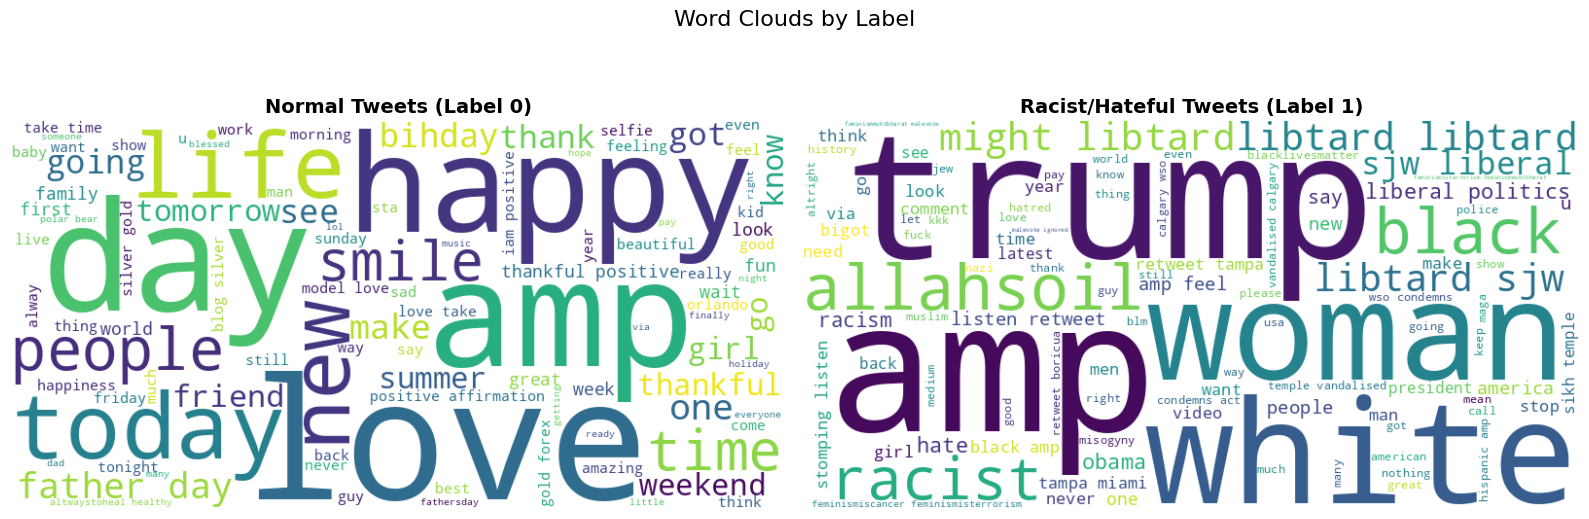

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for label, ax in zip([0, 1], axes):
    text = ' '.join(df[df['label'] == label]['cleaned_tweet'])
    wc = WordCloud(width=800, height=400, background_color='white',
                   max_words=100, colormap='viridis').generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title("Normal Tweets (Label 0)" if label == 0 else "Racist/Hateful Tweets (Label 1)",
                 fontsize=14, fontweight='bold')

plt.suptitle("Word Clouds by Label", fontsize=16)
plt.tight_layout()
plt.savefig('wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()

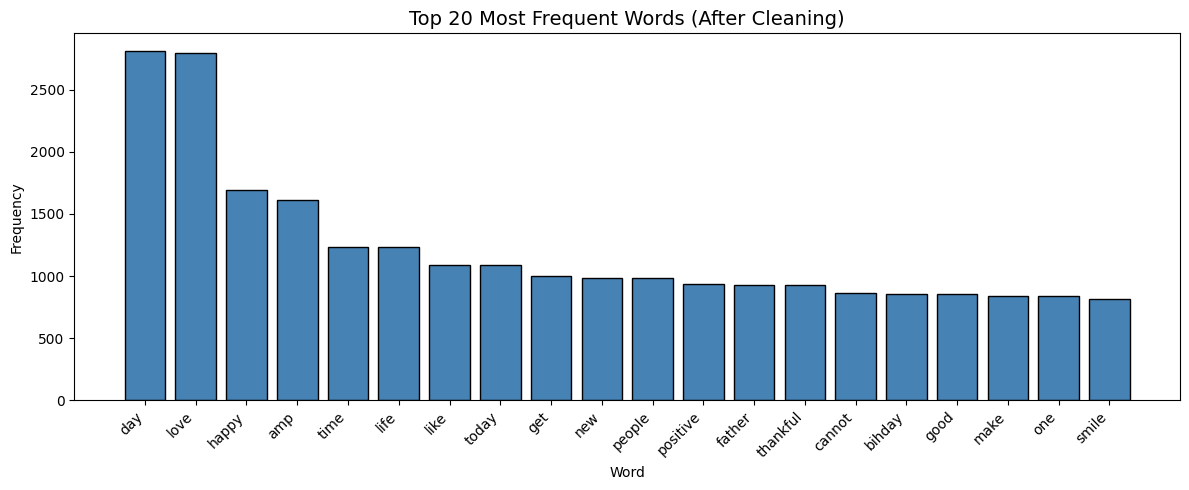

In [11]:
all_words = ' '.join(df['cleaned_tweet']).split()
word_counts = Counter(all_words)
top_20 = word_counts.most_common(20)
words, counts = zip(*top_20)

plt.figure(figsize=(12, 5))
plt.bar(words, counts, color='steelblue', edgecolor='black')
plt.xticks(rotation=45, ha='right')
plt.title('Top 20 Most Frequent Words (After Cleaning)', fontsize=14)
plt.xlabel('Word')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('top_words.png', dpi=150, bbox_inches='tight')
plt.show()

## Train / Test Split

In [12]:
X_raw = df['cleaned_tweet'].values
X_orig = df['tweet'].values          # kept for error analysis display
y = df['label'].values

X_train, X_test, y_train, y_test, X_train_orig, X_test_orig = train_test_split(
    X_raw, y, X_orig,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Training samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")
print("\nLabel distribution in training set:")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Label {u}: {c} ({c/len(y_train)*100:.1f}%)")

Training samples: 25538
Testing samples:  6385

Label distribution in training set:
  Label 0: 23748 (93.0%)
  Label 1: 1790 (7.0%)


## Tokenisation

In [13]:
VOCAB_SIZE = 10000

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)          # vocabulary built from training data only

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

print("Example tweet (cleaned):  ", X_train[0])
print("Example tweet (integers): ", X_train_seq[0])
print(f"\nUnique words in training vocab: {len(tokenizer.word_index)}")
print(f"Keeping top {VOCAB_SIZE}")

Example tweet (cleaned):   fucking parrot get fucking smashing cage
Example tweet (integers):  [560, 1, 10, 560, 1, 3197]

Unique words in training vocab: 32218
Keeping top 10000


## Sequence Padding

In [14]:
all_lengths = [len(seq) for seq in X_train_seq]
MAX_LEN = int(np.percentile(all_lengths, 95))
print(f"95th percentile tweet length: {MAX_LEN} tokens → used as MAX_LEN")

# padding='post' appends zeros after the words; truncating='post' cuts from the end
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

print(f"\nTraining set shape: {X_train_pad.shape}")
print(f"Test set shape:     {X_test_pad.shape}")

95th percentile tweet length: 13 tokens → used as MAX_LEN

Training set shape: (25538, 13)
Test set shape:     (6385, 13)


## Class Weights

In [15]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=y_train
)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}
print("Class weights:", class_weight_dict)
print("(Label 1 errors are penalised ~13× more than Label 0 errors)")

Class weights: {0: np.float64(0.5376873842007748), 1: np.float64(7.133519553072626)}
(Label 1 errors are penalised ~13× more than Label 0 errors)


## Shared Utilities

In [16]:
def plot_history(history, model_name):
    """Plot training vs validation loss and accuracy for a trained model."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(history.history['loss'],     label='Training Loss',   linewidth=2)
    ax1.plot(history.history['val_loss'], label='Validation Loss', linewidth=2, linestyle='--')
    ax1.set_title(f'{model_name} — Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(history.history['accuracy'],     label='Training Accuracy',   linewidth=2)
    ax2.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2, linestyle='--')
    ax2.set_title(f'{model_name} — Accuracy')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{model_name.replace(" ", "_")}_history.png', dpi=150, bbox_inches='tight')
    plt.show()

In [17]:
def evaluate_model(model, X_test, y_test, model_name):
    """Print loss, accuracy, classification report, and confusion matrix."""
    y_pred_prob = model.predict(X_test, verbose=0).flatten()
    y_pred = (y_pred_prob >= 0.5).astype(int)

    loss, acc = model.evaluate(X_test, y_test, verbose=0)

    print(f"\nModel: {model_name}")
    print(f"Test Loss:     {loss:.4f}")
    print(f"Test Accuracy: {acc:.4f} ({acc*100:.2f}%)")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred,
                                target_names=['Normal (0)', 'Racist/Hateful (1)']))

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Normal', 'Racist/Hateful'])
    fig, ax = plt.subplots(figsize=(6, 5))
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Confusion Matrix — {model_name}')
    plt.tight_layout()
    plt.savefig(f'cm_{model_name.replace(" ", "_")}.png', dpi=150, bbox_inches='tight')
    plt.show()

    return acc, y_pred

## Model 1 — Simple RNN
### Build

In [18]:
EMBEDDING_DIM = 64

model1 = Sequential(name="SimpleRNN_Model")
model1.add(Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_LEN))
model1.add(SimpleRNN(64, return_sequences=False))  # processes the sequence, returns final state
model1.add(Dropout(0.3))
model1.add(Dense(1, activation='sigmoid'))          # sigmoid outputs a probability between 0 and 1

model1.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model1.build(input_shape=(None, MAX_LEN))
model1.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "SimpleRNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 13, 64)         │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 648,321 (2.47 MB)

 Trainable params: 648,321 (2.47 MB)

 Non-trainable params: 0 (0.00 B)

### Train

In [19]:
history1 = model1.fit(
    X_train_pad, y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    class_weight=class_weight_dict,
    callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)],
    verbose=1
)
print("Model 1 training complete!")

Epoch 1/20
360/360 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.8162 - loss: 0.4150 - val_accuracy: 0.8876 - val_loss: 0.2733
Epoch 2/20
360/360 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9509 - loss: 0.1284 - val_accuracy: 0.9115 - val_loss: 0.2096
Epoch 3/20
360/360 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9786 - loss: 0.0646 - val_accuracy: 0.9084 - val_loss: 0.2626
Epoch 4/20
360/360 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9882 - loss: 0.0334 - val_accuracy: 0.9428 - val_loss: 0.2091
Epoch 5/20
360/360 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.9910 - loss: 0.0266 - val_accuracy: 0.9483 - val_loss: 0.1940
Epoch 6/20
360/360 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9938 - loss: 0.0183 - val_accuracy: 0.9428 - val_loss: 0.2233
Epoch 7/20
360/360 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.9946 - loss: 0.0175 - val_accuracy: 0.9225 - val_loss: 0.2599
Epoch 8/20
360/360 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9941 - loss: 0.0173 - val_accu

### Evaluate

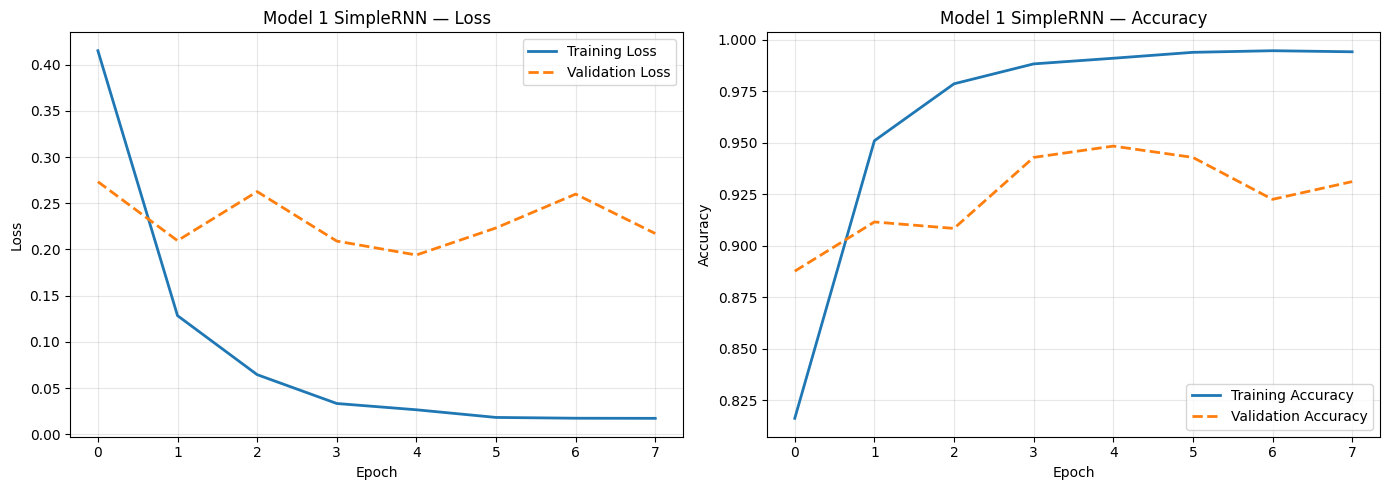


Model: Model 1 SimpleRNN
Test Loss:     0.1937
Test Accuracy: 0.9516 (95.16%)

Classification Report:
                    precision    recall  f1-score   support

        Normal (0)       0.97      0.98      0.97      5937
Racist/Hateful (1)       0.67      0.61      0.64       448

          accuracy                           0.95      6385
         macro avg       0.82      0.79      0.81      6385
      weighted avg       0.95      0.95      0.95      6385



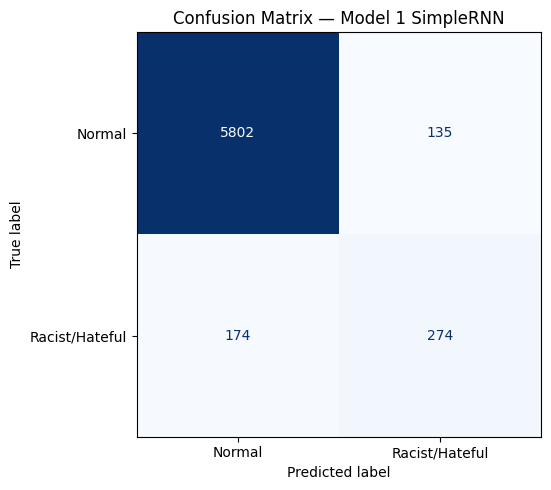

In [20]:
plot_history(history1, "Model 1 SimpleRNN")
acc1, pred1 = evaluate_model(model1, X_test_pad, y_test, "Model 1 SimpleRNN")

## Model 2 — LSTM
### Build

In [21]:
model2 = Sequential(name="LSTM_Model")
model2.add(Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM, input_length=MAX_LEN))
model2.add(LSTM(64, return_sequences=False))
model2.add(Dropout(0.3))
model2.add(Dense(1, activation='sigmoid'))

model2.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model2.build(input_shape=(None, MAX_LEN))
model2.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 13, 64)         │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 673,089 (2.57 MB)

 Trainable params: 673,089 (2.57 MB)

 Non-trainable params: 0 (0.00 B)

### Train

In [22]:
history2 = model2.fit(
    X_train_pad, y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    class_weight=class_weight_dict,
    callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)],
    verbose=1
)
print("Model 2 training complete!")

Epoch 1/20
360/360 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - accuracy: 0.8125 - loss: 0.4086 - val_accuracy: 0.8841 - val_loss: 0.2733
Epoch 2/20
360/360 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - accuracy: 0.9333 - loss: 0.1805 - val_accuracy: 0.9193 - val_loss: 0.1929
Epoch 3/20
360/360 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.9557 - loss: 0.1105 - val_accuracy: 0.9213 - val_loss: 0.1992
Epoch 4/20
360/360 ━━━━━━━━━━━━━━━━━━━━ 8s 17ms/step - accuracy: 0.9737 - loss: 0.0653 - val_accuracy: 0.9487 - val_loss: 0.2073
Epoch 5/20
360/360 ━━━━━━━━━━━━━━━━━━━━ 8s 23ms/step - accuracy: 0.9803 - loss: 0.0467 - val_accuracy: 0.9393 - val_loss: 0.2383
Model 2 training complete!



### Evaluate

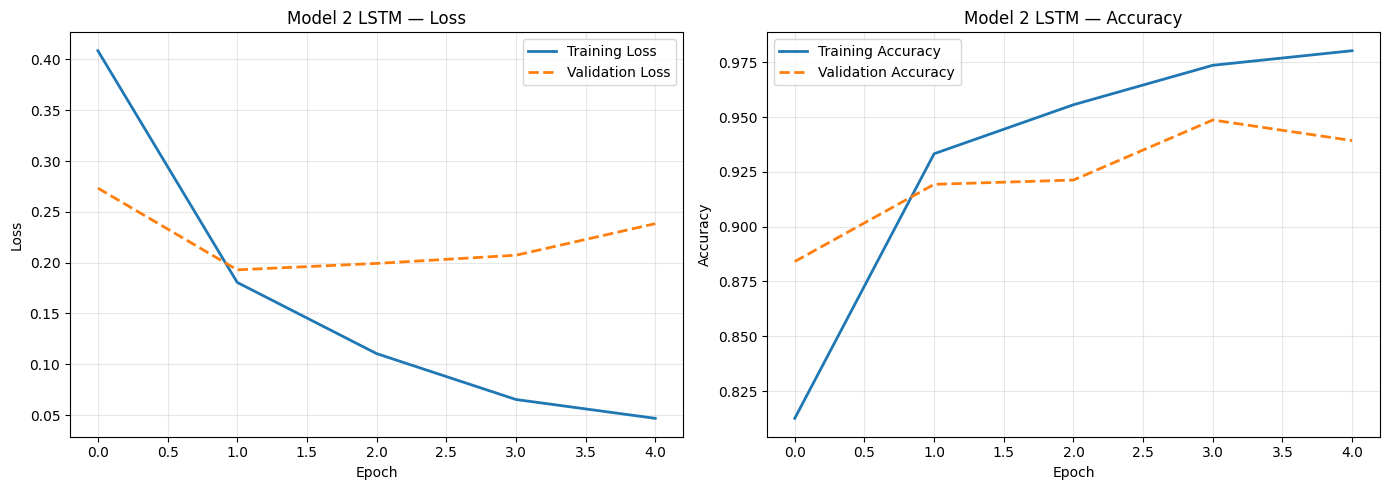


Model: Model 2 LSTM
Test Loss:     0.2011
Test Accuracy: 0.9135 (91.35%)

Classification Report:
                    precision    recall  f1-score   support

        Normal (0)       0.98      0.92      0.95      5937
Racist/Hateful (1)       0.44      0.81      0.57       448

          accuracy                           0.91      6385
         macro avg       0.71      0.86      0.76      6385
      weighted avg       0.95      0.91      0.92      6385



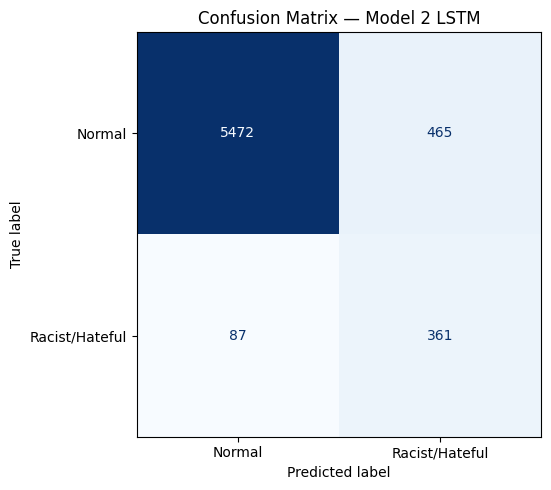

In [23]:
plot_history(history2, "Model 2 LSTM")
acc2, pred2 = evaluate_model(model2, X_test_pad, y_test, "Model 2 LSTM")

## Model 3 — LSTM with Pre-trained GloVe Embeddings
### Download Glove

In [24]:
if not os.path.exists('glove.6B.50d.txt'):
    print("Downloading GloVe vectors... (2–3 minutes)")
    urllib.request.urlretrieve(
        "https://nlp.stanford.edu/data/glove.6B.zip",
        "glove.6B.zip"
    )
    with zipfile.ZipFile("glove.6B.zip", "r") as z:
        z.extract("glove.6B.50d.txt")
    print("Downloaded!")
else:
    print("GloVe file already present, skipping download.")

# Load vectors into a dictionary: word → 50-dimensional numpy array
embedding_model = {}
with open("glove.6B.50d.txt", encoding="utf-8") as f:
    for line in f:
        values = line.split()
        embedding_model[values[0]] = np.array(values[1:], dtype='float32')

print(f"Loaded {len(embedding_model):,} word vectors.")
print(f"Example — 'hate': {embedding_model['hate'][:5]}")

Downloaded!
Loaded 400,000 word vectors.
Example — 'hate': [-0.85233  -0.14749   0.049936 -0.7872    0.19493 ]


### Build Embedding Matrix

In [25]:
EMBEDDING_DIM_GLOVE = 50    # must match the downloaded GloVe dimension

embedding_matrix = np.zeros((VOCAB_SIZE, EMBEDDING_DIM_GLOVE))
words_found, words_not_found = 0, 0

for word, i in tokenizer.word_index.items():
    if i >= VOCAB_SIZE:
        continue
    if word in embedding_model:
        embedding_matrix[i] = embedding_model[word]
        words_found += 1
    else:
        words_not_found += 1   # zero vector — no GloVe representation

print(f"Words matched in GloVe:      {words_found}")
print(f"Words not in GloVe (zeroed): {words_not_found}")
print(f"Embedding matrix shape:      {embedding_matrix.shape}")

Words matched in GloVe:      7975
Words not in GloVe (zeroed): 2024
Embedding matrix shape:      (10000, 50)


### Build Model

In [26]:
model3 = Sequential(name="LSTM_GloVe_Model")
model3.add(Embedding(
    input_dim=VOCAB_SIZE,
    output_dim=EMBEDDING_DIM_GLOVE,
    weights=[embedding_matrix],     # initialise with GloVe vectors
    input_length=MAX_LEN,
    trainable=False                 # keep GloVe vectors fixed
))
model3.add(LSTM(64, return_sequences=False))
model3.add(Dropout(0.3))
model3.add(Dense(1, activation='sigmoid'))

model3.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
model3.build(input_shape=(None, MAX_LEN))
model3.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "LSTM_GloVe_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 13, 50)         │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        29,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 529,505 (2.02 MB)

 Trainable params: 29,505 (115.25 KB)

 Non-trainable params: 500,000 (1.91 MB)

### Train

In [27]:
history3 = model3.fit(
    X_train_pad, y_train,
    epochs=20,
    batch_size=64,
    validation_split=0.1,
    class_weight=class_weight_dict,
    callbacks=[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)],
    verbose=1
)
print("Model 3 training complete!")

Epoch 1/20
360/360 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.8048 - loss: 0.4697 - val_accuracy: 0.8727 - val_loss: 0.3346
Epoch 2/20
360/360 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - accuracy: 0.8375 - loss: 0.3823 - val_accuracy: 0.8677 - val_loss: 0.3104
Epoch 3/20
360/360 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.8435 - loss: 0.3454 - val_accuracy: 0.8884 - val_loss: 0.3139
Epoch 4/20
360/360 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.8570 - loss: 0.3256 - val_accuracy: 0.8469 - val_loss: 0.3528
Epoch 5/20
360/360 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - accuracy: 0.8655 - loss: 0.2946 - val_accuracy: 0.8583 - val_loss: 0.3257
Model 3 training complete!


### Evaluate

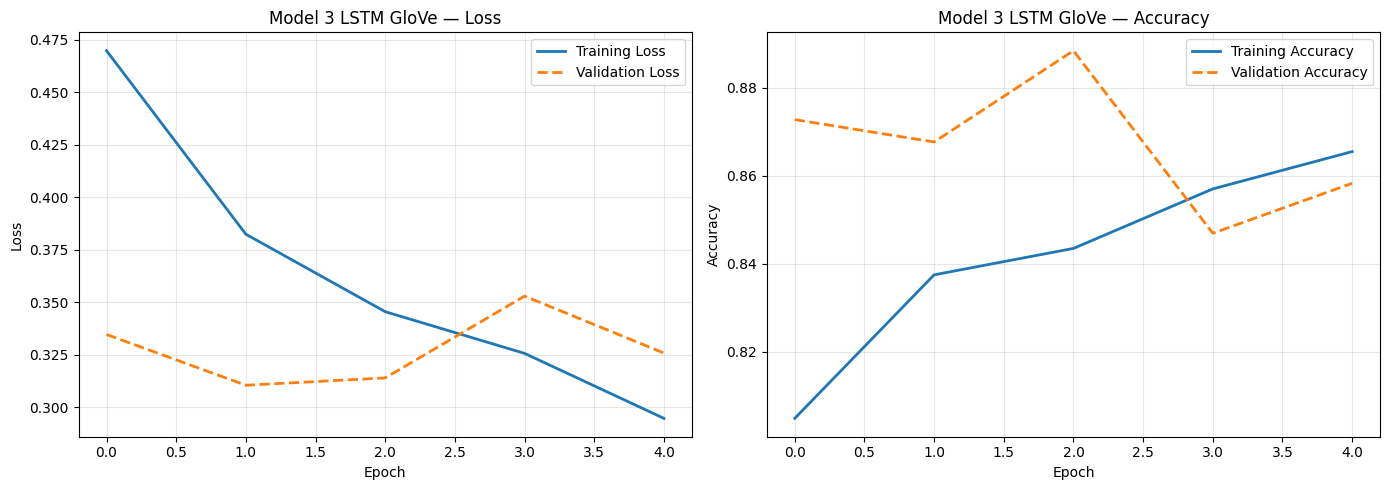


Model: Model 3 LSTM GloVe
Test Loss:     0.3339
Test Accuracy: 0.8531 (85.31%)

Classification Report:
                    precision    recall  f1-score   support

        Normal (0)       0.98      0.86      0.92      5937
Racist/Hateful (1)       0.29      0.79      0.43       448

          accuracy                           0.85      6385
         macro avg       0.64      0.82      0.67      6385
      weighted avg       0.93      0.85      0.88      6385



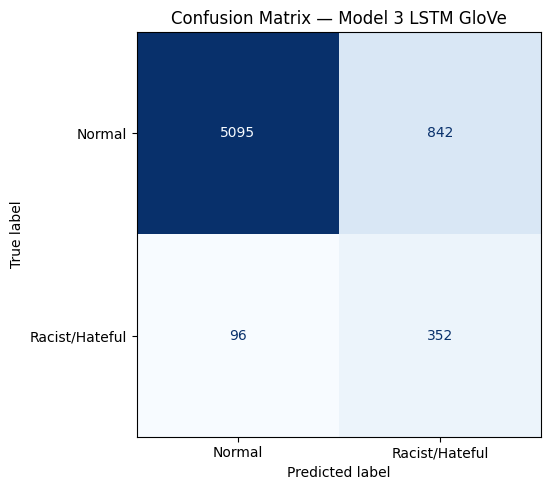

In [28]:
plot_history(history3, "Model 3 LSTM GloVe")
acc3, pred3 = evaluate_model(model3, X_test_pad, y_test, "Model 3 LSTM GloVe")

## Model Comparison

Model Comparison:
                Model  Test Accuracy
   Model 1\nSimpleRNN       0.951605
        Model 2\nLSTM       0.913547
Model 3\nLSTM + GloVe       0.853093


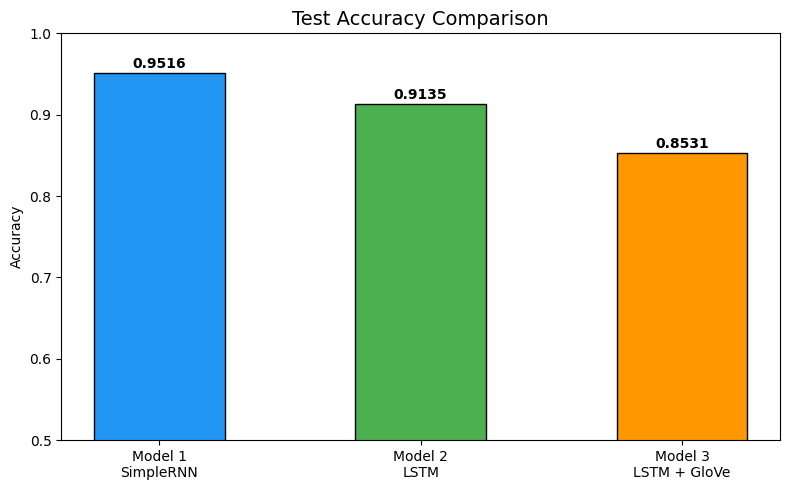

In [29]:
comparison = pd.DataFrame({
    'Model': ['Model 1\nSimpleRNN', 'Model 2\nLSTM', 'Model 3\nLSTM + GloVe'],
    'Test Accuracy': [acc1, acc2, acc3]
})

print("Model Comparison:")
print(comparison.to_string(index=False))

plt.figure(figsize=(8, 5))

bars = plt.bar(
    comparison['Model'],
    comparison['Test Accuracy'],
    color=['#2196F3', '#4CAF50', '#FF9800'],
    edgecolor='black',
    width=0.5
)

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2.,
        height + 0.002,
        f'{height:.4f}',
        ha='center',
        va='bottom',
        fontweight='bold'
    )

plt.ylim(0.5, 1.0)
plt.title('Test Accuracy Comparison', fontsize=14)
plt.ylabel('Accuracy')

plt.tight_layout()

plt.savefig(
    'model_comparison.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

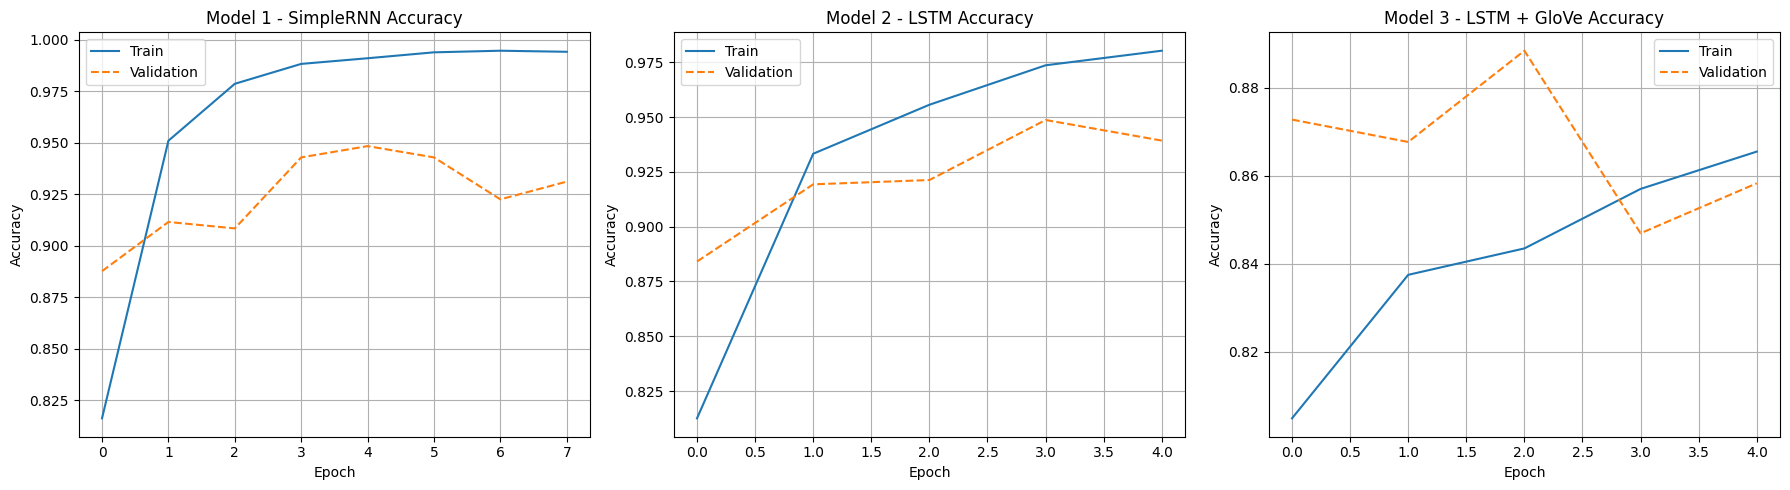

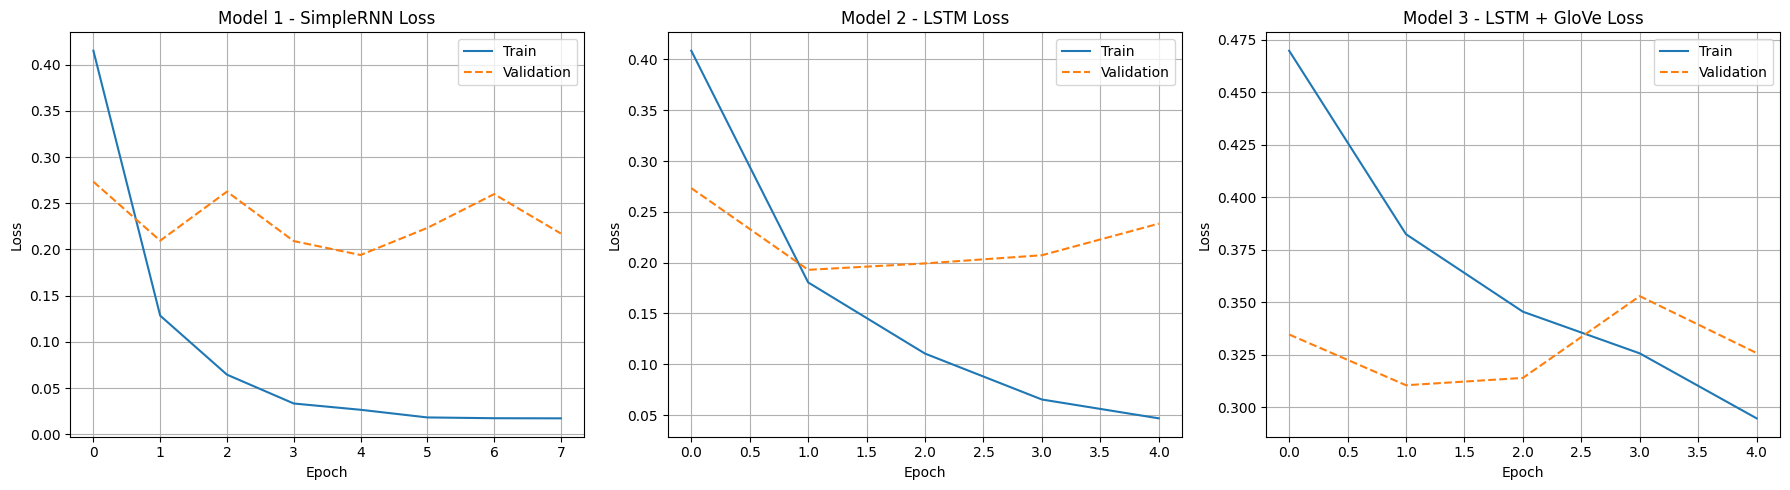

In [35]:
# ACCURACY GRAPHS
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# Model 1
ax[0].plot(history1.history['accuracy'], label='Train')
ax[0].plot(history1.history['val_accuracy'], '--', label='Validation')
ax[0].set_title('Model 1 - SimpleRNN Accuracy')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Accuracy')
ax[0].legend()
ax[0].grid(True)

# Model 2
ax[1].plot(history2.history['accuracy'], label='Train')
ax[1].plot(history2.history['val_accuracy'], '--', label='Validation')
ax[1].set_title('Model 2 - LSTM Accuracy')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Accuracy')
ax[1].legend()
ax[1].grid(True)

# Model 3
ax[2].plot(history3.history['accuracy'], label='Train')
ax[2].plot(history3.history['val_accuracy'], '--', label='Validation')
ax[2].set_title('Model 3 - LSTM + GloVe Accuracy')
ax[2].set_xlabel('Epoch')
ax[2].set_ylabel('Accuracy')
ax[2].legend()
ax[2].grid(True)

plt.tight_layout()
plt.show()


# LOSS GRAPHS

fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# Model 1
ax[0].plot(history1.history['loss'], label='Train')
ax[0].plot(history1.history['val_loss'], '--', label='Validation')
ax[0].set_title('Model 1 - SimpleRNN Loss')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Loss')
ax[0].legend()
ax[0].grid(True)

# Model 2
ax[1].plot(history2.history['loss'], label='Train')
ax[1].plot(history2.history['val_loss'], '--', label='Validation')
ax[1].set_title('Model 2 - LSTM Loss')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Loss')
ax[1].legend()
ax[1].grid(True)

# Model 3
ax[2].plot(history3.history['loss'], label='Train')
ax[2].plot(history3.history['val_loss'], '--', label='Validation')
ax[2].set_title('Model 3 - LSTM + GloVe Loss')
ax[2].set_xlabel('Epoch')
ax[2].set_ylabel('Loss')
ax[2].legend()
ax[2].grid(True)

plt.tight_layout()
plt.show()

## Error Analysis

In [31]:
wrong_mask = (pred2 != y_test)
wrong_indices = np.where(wrong_mask)[0]

print(f"Model 2 misclassified {wrong_mask.sum()} / {len(y_test)} tweets  "
      f"({wrong_mask.mean()*100:.2f}% error rate)\n")

Model 2 misclassified 552 / 6385 tweets  (8.65% error rate)



In [32]:
print("Misclassified Examples\n")

for i, idx in enumerate(wrong_indices[:3]):
    true_label = "Racist/Hateful" if y_test[idx] == 1 else "Normal"
    pred_label = "Racist/Hateful" if pred2[idx] == 1 else "Normal"
    error_type = "False Positive (flagged incorrectly)" if pred2[idx] == 1 \
                 else "False Negative (missed hate speech)"

    print(f"Example {i + 1}")
    print(f"  Original tweet : {X_test_orig[idx]}")
    print(f"  Cleaned tweet  : {X_test[idx]}")
    print(f"  True label     : {true_label}")
    print(f"  Predicted label: {pred_label}")
    print(f"  Error type     : {error_type}\n")

Misclassified Examples

Example 1
  Original tweet : all the man that i need â£  mycaptainamerica ð i miss you ð¸ð¼    #tranny #ladyboyâ¦ 
  Cleaned tweet  : man need mycaptainamerica miss tranny ladyboy
  True label     : Normal
  Predicted label: Racist/Hateful
  Error type     : False Positive (flagged incorrectly)

Example 2
  Original tweet : my bestfriend is back in piedmont alabama aka usa &amp; i've been good the whole time she was gone â¼ï¸â¼ï¸   
  Cleaned tweet  : bestfriend back piedmont alabama aka usa amp good whole time gone
  True label     : Normal
  Predicted label: Racist/Hateful
  Error type     : False Positive (flagged incorrectly)

Example 3
  Original tweet :   #shenanigans  w/the right person to the right degree @ the right time  for the right purpose in the right way 
  Cleaned tweet  : shenanigan wthe right person right degree right time right purpose right way
  True label     : Normal
  Predicted label: Racist/Hateful
  Error type     : False P

In [33]:
print("Error Analysis\n")

print(
    "Reasons for misclassification:\n"
    "1. Class imbalance: The dataset contains far more normal tweets than hateful ones, "
    "so the model sees fewer hateful examples during training, leading to more false negatives.\n\n"

    "2. Sarcasm and reclaimed language: Some tweets use offensive words jokingly or in a non-hateful way. "
    "The model cannot understand tone or cultural context, so these are often misclassified.\n\n"

    "3. Very short tweets after cleaning: Removing URLs, mentions, and stopwords can leave very little text, "
    "making it difficult for the model to understand context.\n\n"

    "4. Out-of-vocabulary terms: Slang, misspellings, or unseen words are replaced with the <OOV> token, "
    "causing loss of meaning."
)

print(
    "\nModel complexity vs performance:\n"
    "SimpleRNN struggles with long-term context because it cannot effectively remember earlier words. "
    "LSTM performs better due to its gating mechanism, which helps retain important sequence information. "
    "Using pretrained GloVe embeddings further improves performance by providing richer word representations."
)

print(
    "\nPotential improvements:\n"
    "- Use Twitter-based GloVe embeddings for better domain matching.\n"
    "- Add a Bidirectional LSTM layer.\n"
    "- Increase embedding dimensions for richer representations.\n"
    "- Apply data augmentation to balance the minority class."
)

Error Analysis

Reasons for misclassification:
1. Class imbalance: The dataset contains far more normal tweets than hateful ones, so the model sees fewer hateful examples during training, leading to more false negatives.

2. Sarcasm and reclaimed language: Some tweets use offensive words jokingly or in a non-hateful way. The model cannot understand tone or cultural context, so these are often misclassified.

3. Very short tweets after cleaning: Removing URLs, mentions, and stopwords can leave very little text, making it difficult for the model to understand context.

4. Out-of-vocabulary terms: Slang, misspellings, or unseen words are replaced with the <OOV> token, causing loss of meaning.

Model complexity vs performance:
SimpleRNN struggles with long-term context because it cannot effectively remember earlier words. LSTM performs better due to its gating mechanism, which helps retain important sequence information. Using pretrained GloVe embeddings further improves performance by pro

## GUI — Real-Time Prediction

In [34]:
import gradio as gr

def predict_tweet(raw_tweet):

    if not raw_tweet.strip():
        return "Please enter a tweet to analyze."

    cleaned = clean_tweet(raw_tweet)

    if not cleaned.strip():
        return "The text became empty after preprocessing. Try another input."

    sequence = tokenizer.texts_to_sequences([cleaned])

    padded = pad_sequences(
        sequence,
        maxlen=MAX_LEN,
        padding='post',
        truncating='post'
    )

    probability = model2.predict(padded, verbose=0)[0][0]

    label = int(probability >= 0.5)

    confidence = probability if label == 1 else (1 - probability)

    if label == 1:
        result = "Hateful / Offensive Tweet Detected"
    else:
        result = "Normal Tweet"

    return (
        f"{result}\n\n"
        f"Confidence Score: {confidence * 100:.2f}%\n\n"
        f"Processed Text:\n{cleaned}"
    )


demo = gr.Interface(
    fn=predict_tweet,

    inputs=gr.Textbox(
        lines=4,
        placeholder="Enter a tweet here...",
        label="Tweet Input"
    ),

    outputs=gr.Textbox(
        lines=7,
        label="Prediction Result"
    ),

    title="Twitter Hate Speech Detection",

    description=(
        "This application uses an LSTM-based deep learning model "
        "to classify tweets as either normal or hateful/offensive."
    ),

    examples=[
        ["Had a great time with my friends today!"],
        ["I hate those people and they should not exist."]
    ],

    theme=gr.themes.Ocean()
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://a9f0128b2fa24910c0.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
